# COVID-19 DIIM Analysis

Run the Dynamic Inoperability Input-Output Model for the COVID-19 scenario,
analyze inoperability evolution, economic losses, and policy impacts.

## 1. Load Libraries & Functions

In [1]:
# Set working directory to project root
setwd("..")

library(openxlsx)
library(ggplot2)
library(reshape2)
library(gridExtra)
library(dplyr)
library(tidyverse)
# Helper: source R code from a Jupyter notebook (.ipynb)
source_notebook <- function(nb_path) {
  nb <- jsonlite::fromJSON(nb_path, simplifyVector = FALSE)
  code_cells <- Filter(function(cell) cell$cell_type == "code", nb$cells)
  code_lines <- unlist(lapply(code_cells, function(cell) {
    paste(unlist(cell$source), collapse = "")
  }))
  all_code <- paste(code_lines, collapse = "\n")
  eval(parse(text = all_code), envir = globalenv())
}

source_notebook("functions.ipynb")

Warning message:
“package ‘openxlsx’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine() masks gridExtra::combine()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


COVID data loaded successfully
Number of sectors: 15 
A matrix dimensions: 15 15 
Total output (x) sum: 1335525 
DIIM simulation completed
Total economic loss: 27391.1 million


## 2. Load COVID Data

In [2]:
data <- download_data()
A <- data$A
x <- data$x
c <- data$c
q0 <- data$q0
c_star <- data$c_star
A_star <- data$A_star

## 3. Run DIIM Model

In [3]:
DIIM_model <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55, total_duration = 751)

## 4. Inoperability Evolution Plot

pdf 
  2

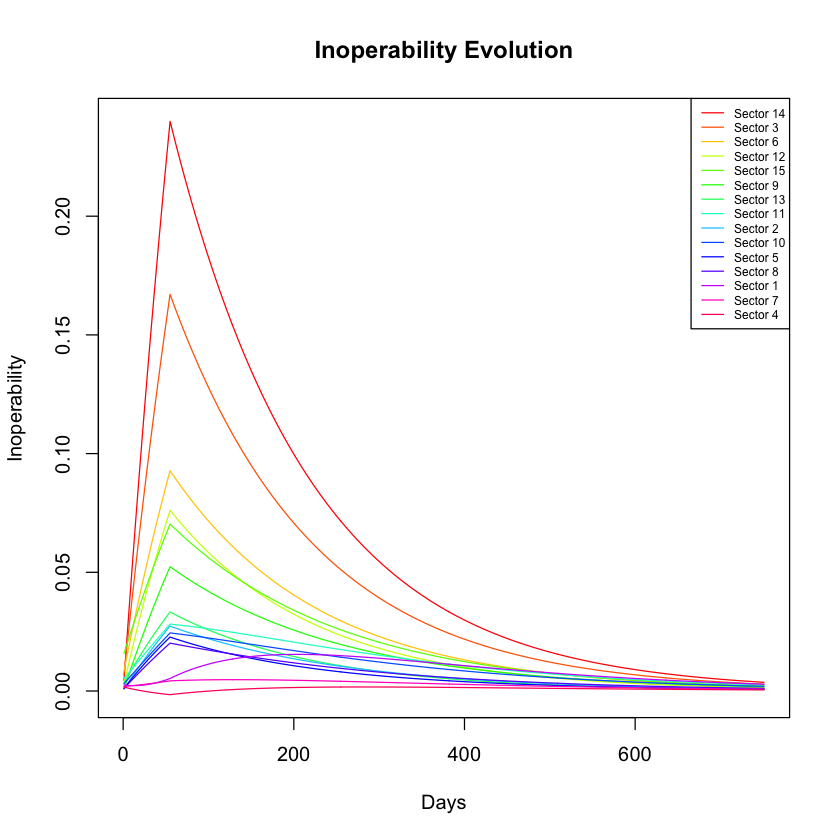

In [4]:
inoperability_evolution <- DIIM_model$inoperability_evolution
max_inoperability <- apply(inoperability_evolution, 1, max)
sorted_indices <- order(max_inoperability, decreasing = TRUE)
sorted_inoperability <- inoperability_evolution[sorted_indices, ]

num_sectors <- nrow(sorted_inoperability)
png("Inoperability_Evolution.png", units = "in", width = 10, height = 7, res = 300)
matplot(t(sorted_inoperability),
        type = "l", lty = 1, col = rainbow(num_sectors),
        xlab = "Days", ylab = "Inoperability",
        main = "Inoperability Evolution")
legend("topright", legend = paste("Sector", sorted_indices), col = rainbow(num_sectors), lty = 1, cex = 0.6)
dev.off()

# Also display inline
matplot(t(sorted_inoperability),
        type = "l", lty = 1, col = rainbow(num_sectors),
        xlab = "Days", ylab = "Inoperability",
        main = "Inoperability Evolution")
legend("topright", legend = paste("Sector", sorted_indices), col = rainbow(num_sectors), lty = 1, cex = 0.6)

## 5. Economic Loss Evolution Plot

pdf 
  2

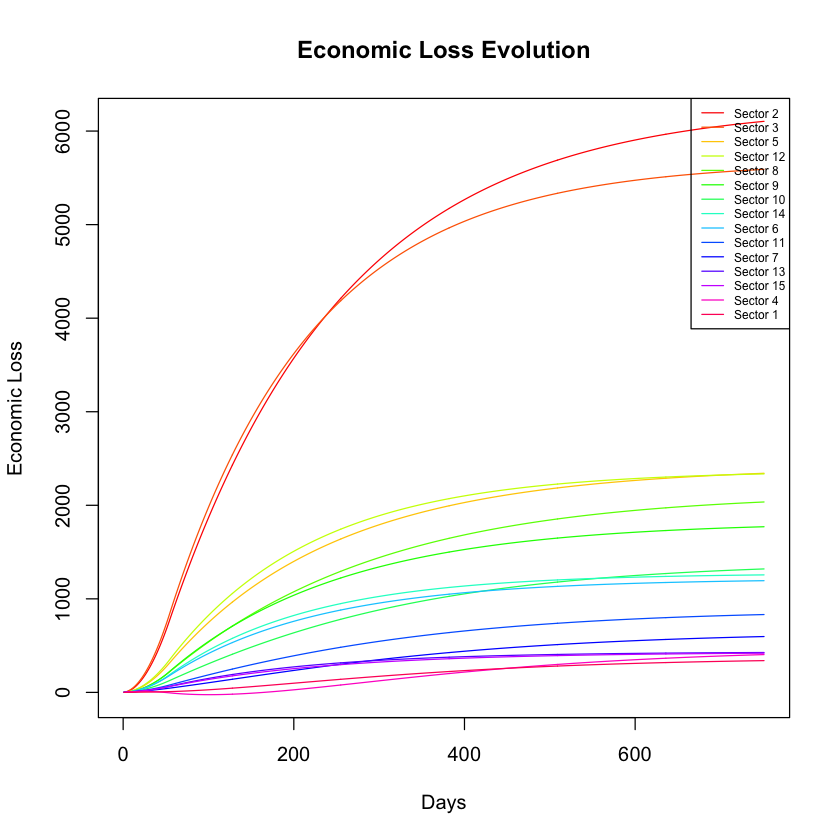

In [5]:
EL_evolution <- DIIM_model$EL_evolution
max_econ_loss <- apply(EL_evolution, 1, max)
sorted_indices <- order(max_econ_loss, decreasing = TRUE)
sorted_econ_loss <- EL_evolution[sorted_indices, ]

num_sectors <- nrow(sorted_econ_loss)
png("Economic_Loss_Evolution.png", units = "in", width = 10, height = 7, res = 300)
matplot(t(sorted_econ_loss),
        type = "l", lty = 1, col = rainbow(num_sectors),
        xlab = "Days", ylab = "Economic Loss",
        main = "Economic Loss Evolution")
legend("topright", legend = paste("Sector", sorted_indices), col = rainbow(num_sectors), lty = 1, cex = 0.6)
dev.off()

# Also display inline
matplot(t(sorted_econ_loss),
        type = "l", lty = 1, col = rainbow(num_sectors),
        xlab = "Days", ylab = "Economic Loss",
        main = "Economic Loss Evolution")
legend("topright", legend = paste("Sector", sorted_indices), col = rainbow(num_sectors), lty = 1, cex = 0.6)

## 6. Sensitivity Analysis: Lockdown Duration

Compare economic loss under 40, 55, and 70 day lockdowns.

In [6]:
output_40_days <- DIIM(q0, A_star, c_star, x, lockdown_duration = 40, total_duration = 751)
economics_loss_40_days <- as.matrix(output_40_days$EL_end)

output_55_days <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55, total_duration = 751)
economics_loss_55_days <- as.matrix(output_55_days$EL_end)

output_70_days <- DIIM(q0, A_star, c_star, x, lockdown_duration = 70, total_duration = 751)
economics_loss_70_days <- as.matrix(output_70_days$EL_end)

cat("40 days total loss:", sum(economics_loss_40_days), "\n")
cat("55 days total loss:", sum(economics_loss_55_days), "\n")
cat("70 days total loss:", sum(economics_loss_70_days), "\n")

40 days total loss: 19918.48 
55 days total loss: 26967.3 
70 days total loss: 33997.68 


## 7. Policy Analysis: Risk Management

In [7]:
policy_j_0 <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55, total_duration = 751, risk_management = 1)
policy_j_1 <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55, total_duration = 751, risk_management = 0.95)

cat("No risk management:", policy_j_0$total_economic_loss, "\n")
cat("5% risk management:", policy_j_1$total_economic_loss, "\n")

policy_j_3 <- DIIM(q0, A_star, c_star, x, lockdown_duration = 55 - 20, total_duration = 751, risk_management = 1)
cat("Reduced lockdown (35 days):", policy_j_3$total_economic_loss, "\n")

No risk management: 26967.3 
5% risk management: 26883.83 
Reduced lockdown (35 days): 17564.99 


## 8. Simulation Loop: ML vs DIIM

In [8]:
lockdown_duration_vals <- c(10, 20, 30, 40)
total_duration_vals <- c(300, 400, 500, 600)

nsim <- length(lockdown_duration_vals) * length(total_duration_vals)

col_names <- c(
        "lockdown_duration",
        "total_duration",
        "model_tot_econ_loss",
        "model_diim_tot_econ_loss",
        "model_ml_tot_econ_loss"
)

sim_matrix <- matrix(data = NA, nrow = nsim, ncol = 5)
colnames(sim_matrix) <- col_names

row_idx <- 1